In [24]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

import time
import psutil
import threading
from memory_profiler import memory_usage

# functions

In [37]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [22]:
def fit_pipeline_with_resources(pipeline, X_train, random_state=42):
    """Trains a pipeline while tracking memory, time, and CPU usage."""
    measurement = {}

    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    def train_model():
        pipeline.fit(X_train)

    try:
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        start_time = time.time()
        # Measure peak memory usage during the pipeline.fit execution
        train_memory = max(memory_usage((train_model,))) 
        training_time = time.time() - start_time

        stop_flag.set()
        cpu_thread.join()

        measurement['Memory Usage (MB)'] = train_memory
        measurement['Training Time (s)'] = training_time
        measurement['Peak CPU Usage (%)'] = max(cpu_usage) if cpu_usage else 0
        measurement['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement, pipeline

    except Exception as e:
        print(f"Error during pipeline training: {e}")
        stop_flag.set()
        return None, None

# loading processed dataset

In [12]:
with open('../config/preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [14]:
dataset_folder = '../dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'dataset_processed.parquet'))
attack_labels_df = df[['Label',"Label_Category"]]
df = df.drop(columns=config['columns_to_drop'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787102 entries, 0 to 787101
Data columns (total 76 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Flow Duration                  787102 non-null  int64  
 1   Total Fwd Packets              787102 non-null  int64  
 2   Total Backward Packets         787102 non-null  int64  
 3   Total Length of Bwd Packets    787102 non-null  int64  
 4   Fwd Packet Length Max          787102 non-null  int64  
 5   Fwd Packet Length Min          787102 non-null  int64  
 6   Fwd Packet Length Std          787102 non-null  float64
 7   Bwd Packet Length Max          787102 non-null  int64  
 8   Bwd Packet Length Min          787102 non-null  int64  
 9   Bwd Packet Length Std          787102 non-null  float64
 10  Flow Bytes/s                   787102 non-null  float64
 11  Flow Packets/s                 787102 non-null  float64
 12  Flow IAT Mean                 

# splitting dataset

In [28]:
# remove novel attacks
mask = attack_labels_df['Label_Category'] != 2

# data to be used will be one with benign/false anomalies

# Preparing features and truth labels
X = df[mask].drop(['Label','anomaly','Label_Category'], axis=1)
y = df[mask]['anomaly']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# scaling dataset

In [ ]:
# Initializing StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test and validation set using the fitted scaler
X_test_scaled = scaler.transform(X_test)

In [30]:
import joblib


if 'standard_scaler.joblib' in os.listdir('../config'):
    scaler_filename = '../config/standard_scaler.joblib'
    scaler = joblib.load(scaler_filename)

    X_train_scaled = scaler.transform(X_train)

else:
    # If no scaler file, initialize StandardScaler
    scaler = StandardScaler()

    # Fit and transform the training data
    X_train_scaled = scaler.fit_transform(X_train)

# Transform the test and validation set using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# XGBoost

## defining model pipeline
XGBoost has been the industry standard, may it be regression or classification problem. It is highly effective as it optimizes both speed and performance, combining boosting, regularization, and efficient computing techniques. There is a saying if you are considering neural networks, try it on xgboost first

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import xgboost as xgb

def run_xgboost_pipeline(X_train, X_test, y_train, y_test, cols_to_drop=None, param_grid=None):
    # 1. Filter Data
    X_train_filtered = X_train.drop(columns=cols_to_drop, errors='ignore') if cols_to_drop else X_train.copy()
    X_test_filtered = X_test.drop(columns=cols_to_drop, errors='ignore') if cols_to_drop else X_test.copy()

    # 2. Calculate Scale Weight (Assuming 0 = Normal, 1 = Anomaly)
    counts = y_train.value_counts()
    # formula: count(negative) / count(positive)
    ratio = counts.get(0, 1) / counts.get(1, 1) 

    # 3. Build Pipeline
    pipeline = Pipeline([
        ('model', xgb.XGBClassifier(
            scale_pos_weight=ratio, 
            objective='binary:logistic',
            use_label_encoder=False,
            eval_metric='aucpr' # Optimize for Precision-Recall during internal boosting
        ))
    ])

    # 4. Parameter Grid (FIX: Added 'model__' prefix)
    if param_grid is None:    
        param_grid = {
            'model__n_estimators': [100, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__min_child_weight': [1, 5], # Essential for anomalies
            'model__subsample': [0.8],
            'model__colsample_bytree': [0.8]
        }

    # 5. Set up Stratified Search
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring='average_precision', # Best for imbalanced anomalies
        cv=cv_strategy, 
        verbose=1, 
        random_state=42,
        n_jobs=-1
    )

    print("Tuning hyperparameters...")
    random_search.fit(X_train_filtered, y_train)

    # 6. Extract Best Model
    final_pipeline = random_search.best_estimator_

    # 7. Generate Anomaly Scores
    # We use predict_proba for the positive class (column 1)
    # Higher score = higher probability of being an anomaly
    anomaly_scores = final_pipeline.predict_proba(X_test_filtered)[:, 1]

    return final_pipeline, random_search.best_params_, anomaly_scores

## Training the model

In [ ]:
xgb_pipeline, best_params, anomaly_scores = run_xgboost_pipeline(X_train_scaled, X_test_scaled, y_train, y_test)

Tuning hyperparameters...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\Nathaniel\Projects\learning-sandbox\aim-capstone\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [19:46:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## save model to reduce headache

In [35]:
import joblib

# Assuming 'final_pipeline' is the output from your run_anomaly_detection_pipeline function
pipeline_filename = '../models/xgb.joblib'

# Export the pipeline to a file
joblib.dump(xgb_pipeline, pipeline_filename)

print(f"Pipeline successfully saved to {pipeline_filename}")

Pipeline successfully saved to ../models/xgb.joblib


## testing model performance on dataset without novel attacks

### ROC and PR Curves

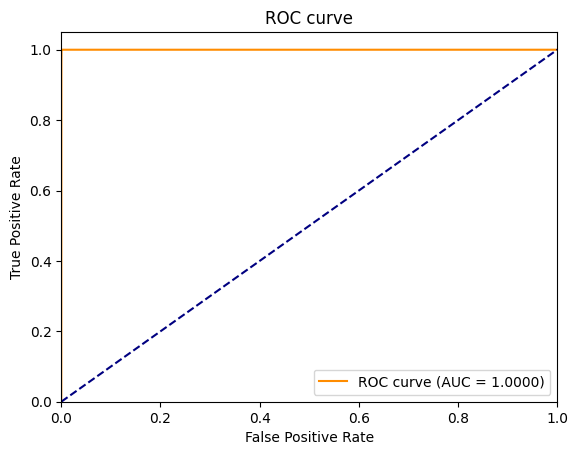

Best threshold:  0.79361755
Best F1-Score:  0.9985310877548436


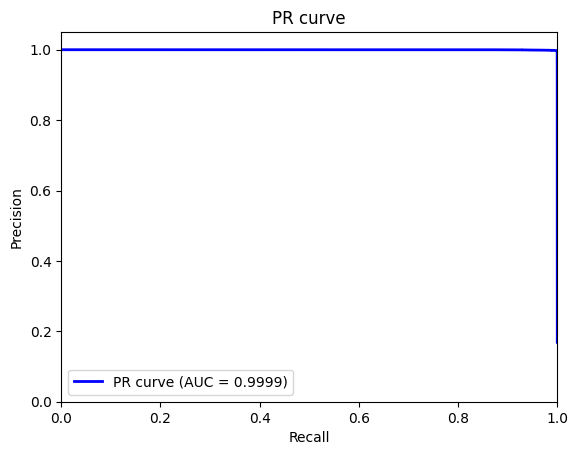

In [38]:
actual_anomaly = y_test

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    anomaly_scores)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    anomaly_scores)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

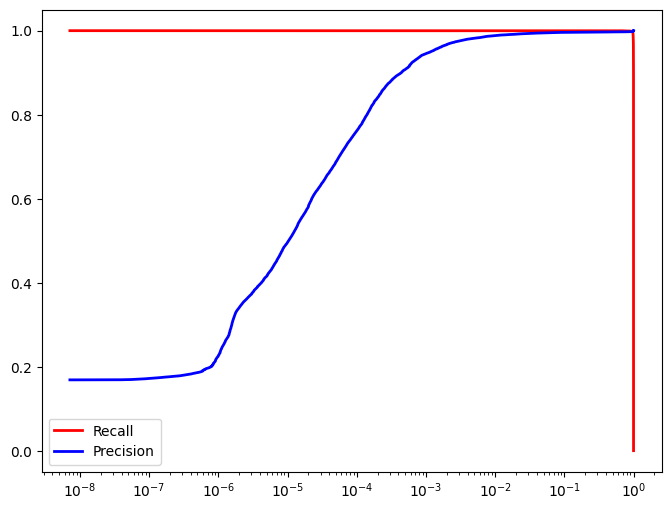

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.xscale('log')
plt.legend()

### finding threshold and classification of anomalies

In [41]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (anomaly_scores >= optimal_threshold).astype(int)

Optimal Threshold: 0.7936175465583801


### Classification Report

In [42]:
from sklearn.metrics import classification_report

# target_names allows you to label the output for better readability
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    194410
     Anomaly       1.00      1.00      1.00     39440

    accuracy                           1.00    233850
   macro avg       1.00      1.00      1.00    233850
weighted avg       1.00      1.00      1.00    233850



### Confusion Matrix

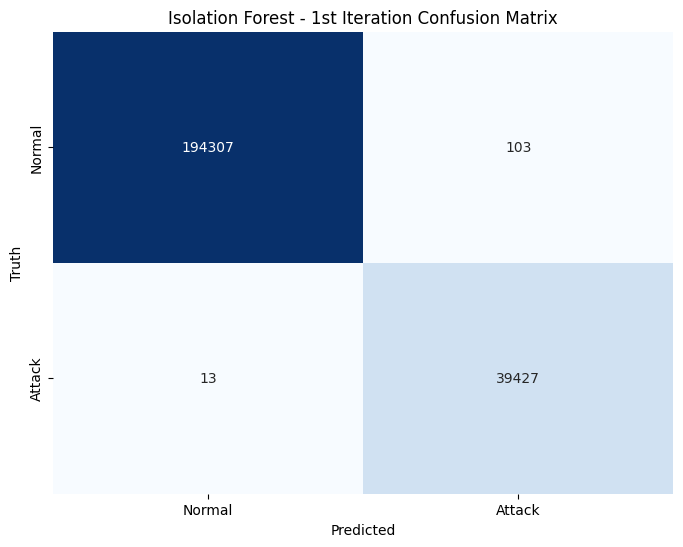

In [43]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 1st Iteration Confusion Matrix')
plt.show()

In [44]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_if).ravel()

# Calculate the False Positive Rate (FPR)
if (fp + tn) != 0:
    fpr = fp / (fp + tn)
else:
    fpr = 0.0 # Handle the edge case of no actual negatives

print(f"False Positive Rate (FPR): {fpr:.4f}")

False Positive Rate (FPR): 0.0005


## testing model performance

In [45]:
# data to be used will be one with benign/false anomalies

# Preparing features and truth labels
X = df.drop(['Label','anomaly','Label_Category'], axis=1)
y = df['anomaly']

# Splitting the data into training and test sets
_, X_test_wnovel, _, y_test_wnovel = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
# Transform the test set using the fitted scaler
X_test_wnovel_scaled = scaler.transform(X_test_wnovel)

In [47]:
anomaly_scores_wnovel = xgb_pipeline.predict_proba(X_test_wnovel_scaled)[:, 1]

In [58]:
xgb_pipeline.predict_proba(X_test_wnovel_scaled)

array([[9.9999905e-01, 9.5401720e-07],
       [9.9999321e-01, 6.8059012e-06],
       [9.9998713e-01, 1.2851609e-05],
       ...,
       [9.9999565e-01, 4.3697837e-06],
       [9.9999267e-01, 7.3128472e-06],
       [9.9999785e-01, 2.1755682e-06]], shape=(236131, 2), dtype=float32)

### ROC and PR Curves

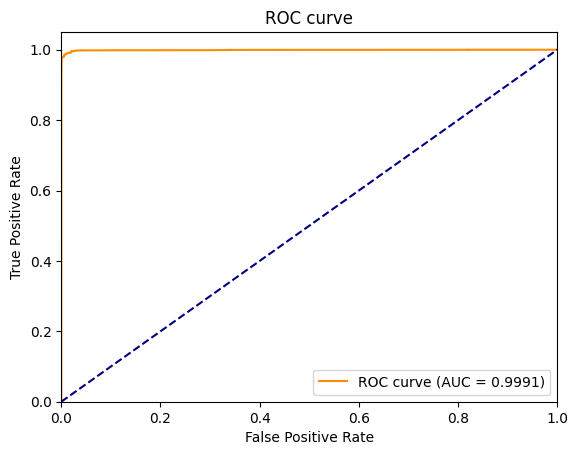

Best threshold:  0.03919482
Best F1-Score:  0.9850565084914478


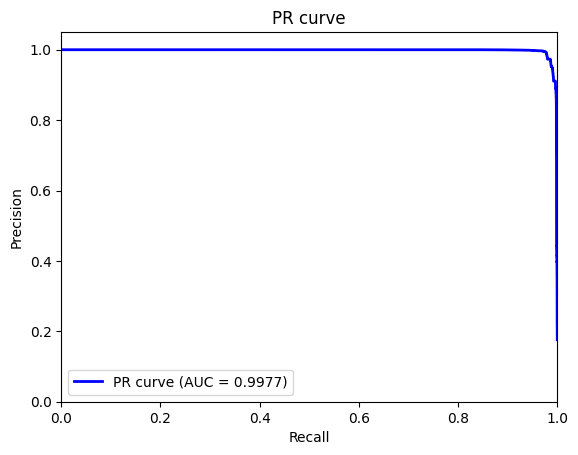

In [50]:
actual_anomaly = y_test_wnovel

fpr, tpr, roc_auc = compute_roc(
    actual_anomaly,
    anomaly_scores_wnovel)

# Plot ROC curve
plot_roc_curve(fpr, tpr, roc_auc, title='ROC curve')


precision, recall, pr_auc, threshold = compute_pr_auc(
    actual_anomaly,
    anomaly_scores_wnovel)
f1_scores = 2 * recall * precision / (recall + precision)
print('Best threshold: ', threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])])
print('Best F1-Score: ', np.max(f1_scores[~np.isnan(f1_scores)]))
# Plot ROC curve
plot_pr_curve(precision, recall, pr_auc, title='PR curve')

### Recall vs Precision across threshold

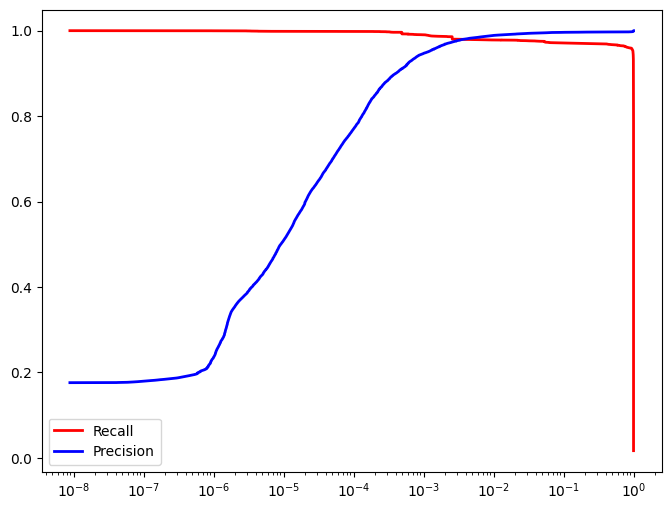

In [51]:
plt.figure(figsize=(8, 6))
plt.plot(threshold, recall[:-1], label='Recall', color='red', linewidth=2,)
plt.plot(threshold, precision[:-1], label='Precision', color='blue', linewidth=2,)
plt.xscale('log')
plt.legend()

### finding threshold and classification of anomalies

In [54]:
from sklearn.metrics import roc_curve, f1_score

# Compute ROC curve to determine optimal threshold for binary classification
fpr, tpr, thresholds = roc_curve(y_test_wnovel, anomaly_scores_wnovel)

# optimal threshold by max f1 score
optimal_threshold = threshold[np.argmax(f1_scores[~np.isnan(f1_scores)])]
print(f'Optimal Threshold: {optimal_threshold}')

# Classify anomalies
y_pred_if = (anomaly_scores_wnovel >= optimal_threshold).astype(int)

Optimal Threshold: 0.03919481858611107


### Classification Report

In [55]:
from sklearn.metrics import classification_report

# target_names allows you to label the output for better readability
print(classification_report(y_test_wnovel, y_pred_if, target_names=['Normal', 'Anomaly'],))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00    194558
     Anomaly       0.99      0.98      0.99     41573

    accuracy                           0.99    236131
   macro avg       0.99      0.99      0.99    236131
weighted avg       0.99      0.99      0.99    236131



### Confusion Matrix

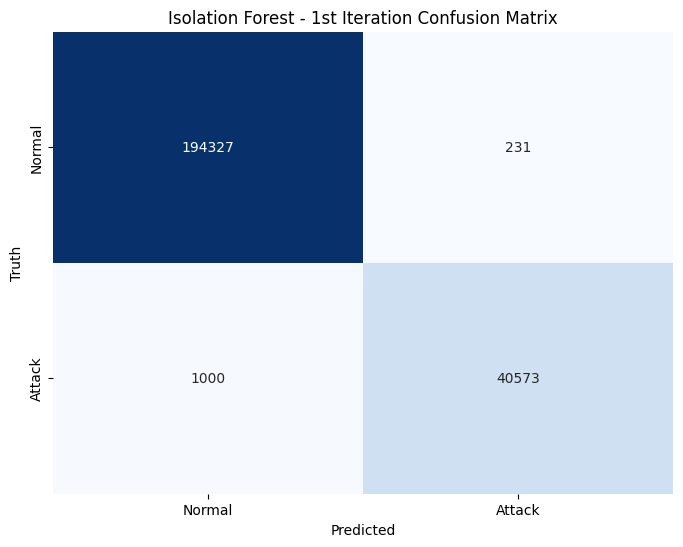

In [56]:
# Confusion Matrix for Binary Classification
cm_kmeans = confusion_matrix(y_test_wnovel, y_pred_if)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_kmeans, annot=True, fmt='d', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'], 
            cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Isolation Forest - 1st Iteration Confusion Matrix')
plt.show()

In [57]:
tn, fp, fn, tp = confusion_matrix(y_test_wnovel, y_pred_if).ravel()

# Calculate the False Positive Rate (FPR)
if (fp + tn) != 0:
    fpr = fp / (fp + tn)
else:
    fpr = 0.0 # Handle the edge case of no actual negatives

print(f"False Positive Rate (FPR): {fpr:.4f}")

False Positive Rate (FPR): 0.0012
